In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.pipeline.props_pipeline.apm_pipeline import apm_pipeline
from src.features.feature_engineer.apm_features import apm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
210,2025-26,1629599,Amir Coffey,Amir,1610612756,PHX,Phoenix Suns,22501185,2026-04-10T00:00:00,PHX @ LAL,L,20.550000,3,6,0.500,1,2,0.500,0,0,0.000,0,2,2,0,1,1,0,0,2,0,7,-11,11.4,0,0,12.0,1,20:33,1,82.4,82.9,82.9,114.2,115.4,115.4,-31.8,-32.5,-32.5,0.000,0.0,0.0,0.000,0.118,0.051,14.3,14.3,0.583,0.583,0.146,0.155,94.22,93.43,77.86,93.43,0.056,41,3.0,6.0,26,77,0.338,7,40,0.175,14,21,0.667,18,29,47,17,23.0,8,1,3,18,18,73,-28.0,80.0,81.1,113.2,112.2,-33.2,-31.1,0.654,0.74,13.2,0.400,0.816,0.570,0.256,0.383,0.423,90.2,90.0,75.00,90,0.255,1610612747,LAL,Los Angeles Lakers,35,69,0.507,8,20,0.400,23,30,0.767,4,31,35,27,11.0,17,3,1,18,18,101,28.0,113.2,112.2,80.0,81.1,33.2,31.1,0.771,2.45,21.8,0.184,0.600,0.430,0.122,0.565,0.614,90.2,90.0,75.00,90,0.745,NaN,SG,28.0,0
211,2025-26,1627739,Kris Dunn,Kris,1610612746,LAC,LA Clippers,22501183,2026-04-10T00:00:00,LAC @ POR,L,26.566667,2,3,0.667,1,2,0.500,0,0,0.000,1,4,5,1,2,0,0,0,4,1,5,3,10.5,0,0,12.0,1,26:34,1,128.6,131.4,131.4,117.5,123.1,123.1,11.2,8.3,8.3,0.043,0.5,16.7,0.042,0.143,0.096,33.3,33.3,0.833,0.833,0.088,0.086,96.26,93.05,77.54,93.05,0.031,51,2.0,3.0,36,83,0.434,13,40,0.325,12,12,1.000,10,25,35,17,17.0,6,3,7,27,15,97,-19.0,101.8,102.1,116.7,122.1,-14.9,-20.0,0.472,1.00,13.8,0.250,0.574,0.411,0.179,0.512,0.549,97.3,95.0,79.17,95,0.350,1610612757,POR,Portland Trail Blazers,37,83,0.446,12,39,0.308,30,35,0.857,14,32,46,23,15.0,12,7,3,15,27,116,19.0,116.7,122.1,101.8,102.1,14.9,20.0,0.622,1.53,16.8,0.426,0.750,0.589,0.158,0.518,0.589,97.3,95.0,79.17,95,0.650,G,PG,31.0,1
212,2025-26,1641771,Jalen Slawson,Jalen,1610612754,IND,Indiana Pacers,22501175,2026-04-10T00:00:00,IND vs. PHI,L,15.183333,0,4,0.000,0,2,0.000,2,2,1.000,2,3,5,3,5,0,1,0,2,3,2,-14,10.5,0,0,12.0,1,15:11,1,59.0,59.4,59.4,101.9,100.0,100.0,-42.8,-40.6,-40.6,0.500,0.6,23.1,0.111,0.125,0.119,38.5,38.8,0.000,0.205,0.270,0.273,102.11,102.74,85.62,102.74,-0.041,32,0.0,4.0,33,88,0.375,14,50,0.280,14,16,0.875,10,42,52,25,21.0,6,8,2,15,14,94,-11.0,88.6,89.5,100.6,101.0,-12.0,-11.4,0.758,1.19,17.5,0.228,0.723,0.492,0.200,0.455,0.495,105.2,104.5,87.08,105,0.456,1610612755,PHI,Philadelphia 76ers,42,104,0.404,5,29,0.172,16,19,0.842,16,42,58,17,8.0,13,2,8,14,15,105,11.0,100.6,101.0,88.6,89.5,12.0,11.4,0.405,2.13,12.2,0.277,0.772,0.508,0.077,0.428,0.467,105.2,104.5,87.08,104,0.544,NaN,SF,26.0,0
205,2025-26,1642362,Payton Sandfort,Payton,1610612760,OKC,

In [3]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["AST_PER_MIN"] = df["AST"] / df["MIN"].replace(0, np.nan)
    df['POSS_PER_MIN'] = df['POSS'] / df['MIN'].replace(0, np.nan)
    df["TOV_PER_MIN"] = df["TOV"] / df["MIN"].replace(0, np.nan)
    df = apm_features(df)
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TOV_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TOV_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    
    df['MEDIAN_AST_PER_MIN_L10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df["AST_ewm3"] = df.groupby("PLAYER_ID")["AST"].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
    df['AST_ewm5'] = (df.groupby('PLAYER_ID')['AST'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['AST_ewm10'] = (df.groupby('PLAYER_ID')['AST'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    # df['AST_TREND'] = df['AST_ewm5'] - df['AST_ewm10']
    df['AST_PER_MIN_ewm10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['AST_PER_MIN_ewm3'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df['AST_PER_MIN_TREND'] = df['AST_PER_MIN_ewm3'] - df['AST_PER_MIN_ewm10']
    df['TOV_PER_MIN_ewm10'] = (df.groupby('PLAYER_ID')['TOV_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))

    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_TREND'] = df['MIN_ewm5'] - df['MIN_ewm10']
    df['USG_TREND'] = df['USG_PCT_roll5'] - df['USG_PCT_roll10']

    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    # df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
    #     lambda x: x.shift(1).rolling(5, min_periods=1).std())
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.to_csv('data/processed/training/S26_TRAINING_APM.csv', index=False)

(84270, 263)


In [4]:
APM_FEATURES = [
    "MIN_ewm10",
    "AST_PER_MIN_season_avg",
    "AST_PER_MIN_ewm10",
    "AST_share_proxy_roll10",
    "TEAM_AST_PER_MIN_RANK_L10",
    "AST_PCT_roll10",
    "TOV_PER_MIN_ewm10",
    "AST_TO_roll10",
    "OPP_DEF_RATING_roll10",
    "OPP_PACE_roll10",
    "PACE_DIFFERENTIAL",
    "TEAM_AST_roll10",
    "TEAM_USG_RANK_L10",
    "ACTIVE_STARS_COUNT",
    "POSITION_ENC",
    "STARTING",
]

In [55]:
from sklearn.preprocessing import StandardScaler

# Define which features to scale (Continuous) vs ignore (Binary/Ordinal)
binary_cols = ['STARTING', 'ACTIVE_STARS_COUNT', 'POSITION_ENC', 'TEAM_AST_PER_MIN_RANK_L10', 'TEAM_USG_RANK_L10']
continuous_cols = [c for c in APM_FEATURES if c not in binary_cols]

ppm_df = df[APM_FEATURES + ["AST_PER_MIN", "MIN", "GAME_DATE"]].dropna()

# 2. Split Data
split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train = ppm_df.loc[train_mask, APM_FEATURES].copy()
X_val = ppm_df.loc[val_mask, APM_FEATURES].copy()
y_train = ppm_df.loc[train_mask, "AST_PER_MIN"]
y_val = ppm_df.loc[val_mask, "AST_PER_MIN"]

# 3. Apply Scaling (Only to continuous features)
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])

# 4. Training Loop
quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    print(f"Training Quantile: {q}...")
    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=1085,
        max_depth=3,
        learning_rate=0.016830306319220507,
        subsample=0.560576121654833,
        colsample_bytree=0.7918682725578758,
        reg_alpha=0.2923179330388192,
        reg_lambda=0.16891787981446876,
        min_child_weight=2,
        n_jobs=-1,
        random_state=42
    )
    xgb_q.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    quantile_models[f"q_{q:.2f}"] = xgb_q
    quantile_preds[f"q_{q:.2f}"] = xgb_q.predict(X_val)

# 5. Diagnostic Output
results = X_val.copy()
results["Actual"] = y_val.values
results["Lower_10"] = quantile_preds["q_0.10"]
results["Median_50"] = quantile_preds["q_0.50"]
results["Upper_90"] = quantile_preds["q_0.90"]

mae = mean_absolute_error(y_val, results["Median_50"])
print(f"\nMedian Model MAE: {mae:.3f} PTS/min")
print(f"Median Model R2: {r2_score(y_val, results['Median_50']):.3f}")


Training Quantile: 0.1...
Training Quantile: 0.5...
Training Quantile: 0.9...

Median Model MAE: 0.055 PTS/min
Median Model R2: 0.343


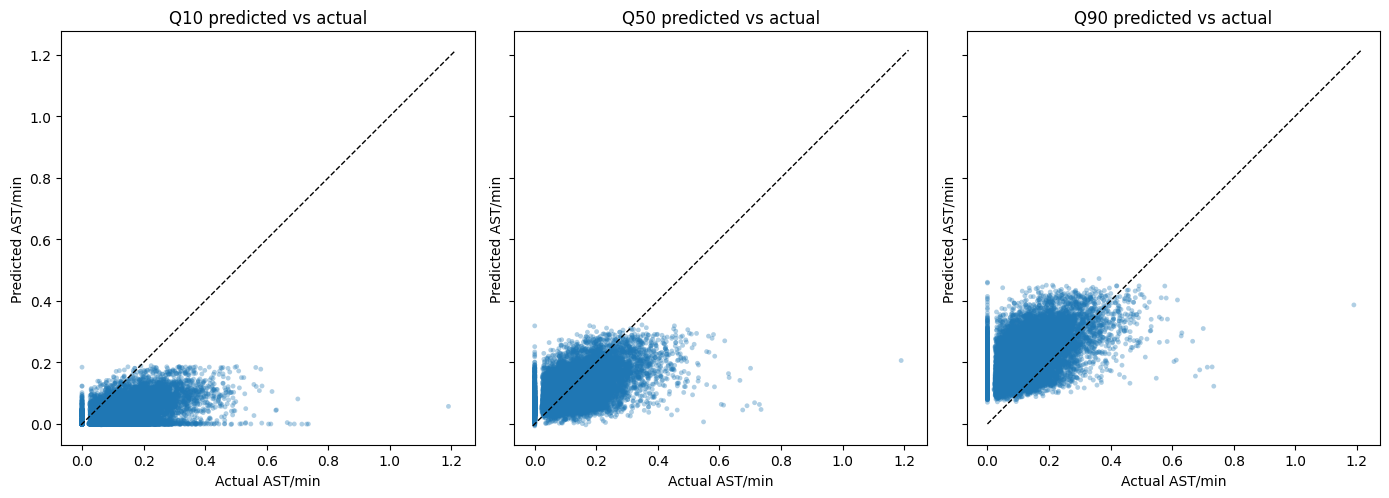

Q10 P(y ≤ pred): 0.10414873472198313
Q50 P(y ≤ pred): 0.5035863889367074
Q90 P(y ≤ pred): 0.8956217363860676
Coverage (10–90 interval): 79.15%


In [56]:
import matplotlib.pyplot as plt

y_true = y_val
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual AST/min")
    ax.set_ylabel("Predicted AST/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

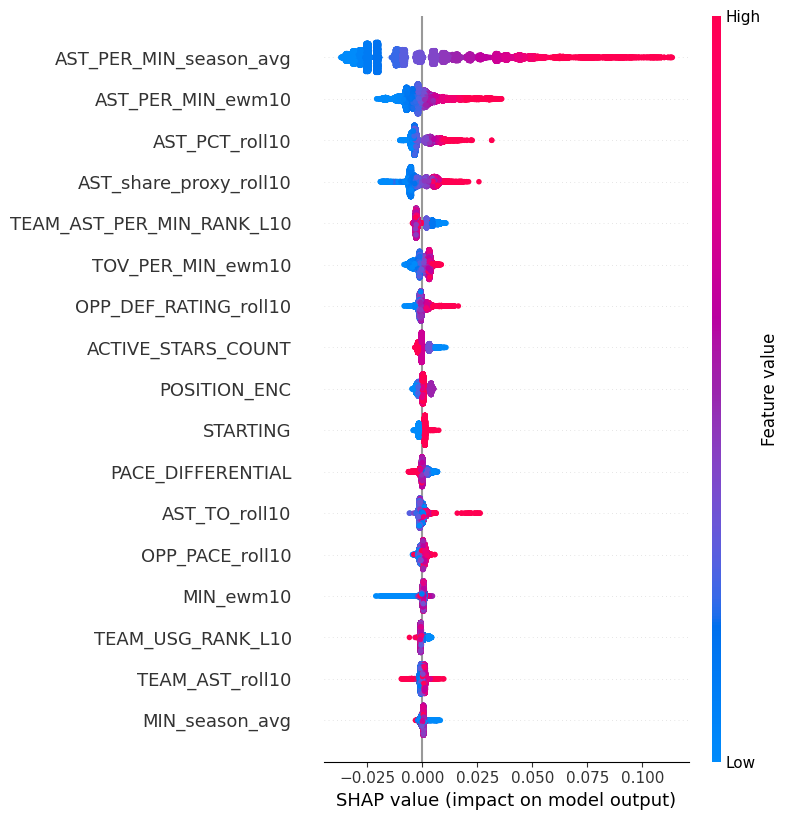

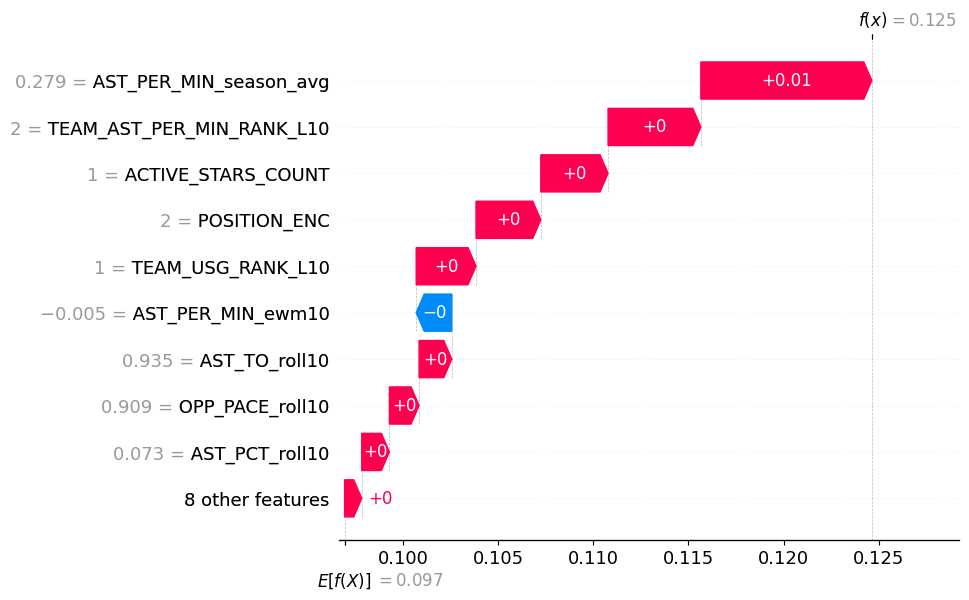

In [57]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val)
shap.summary_plot(shap_values, X_val, feature_names=APM_FEATURES)
shap.plots.waterfall(shap_values[1154])

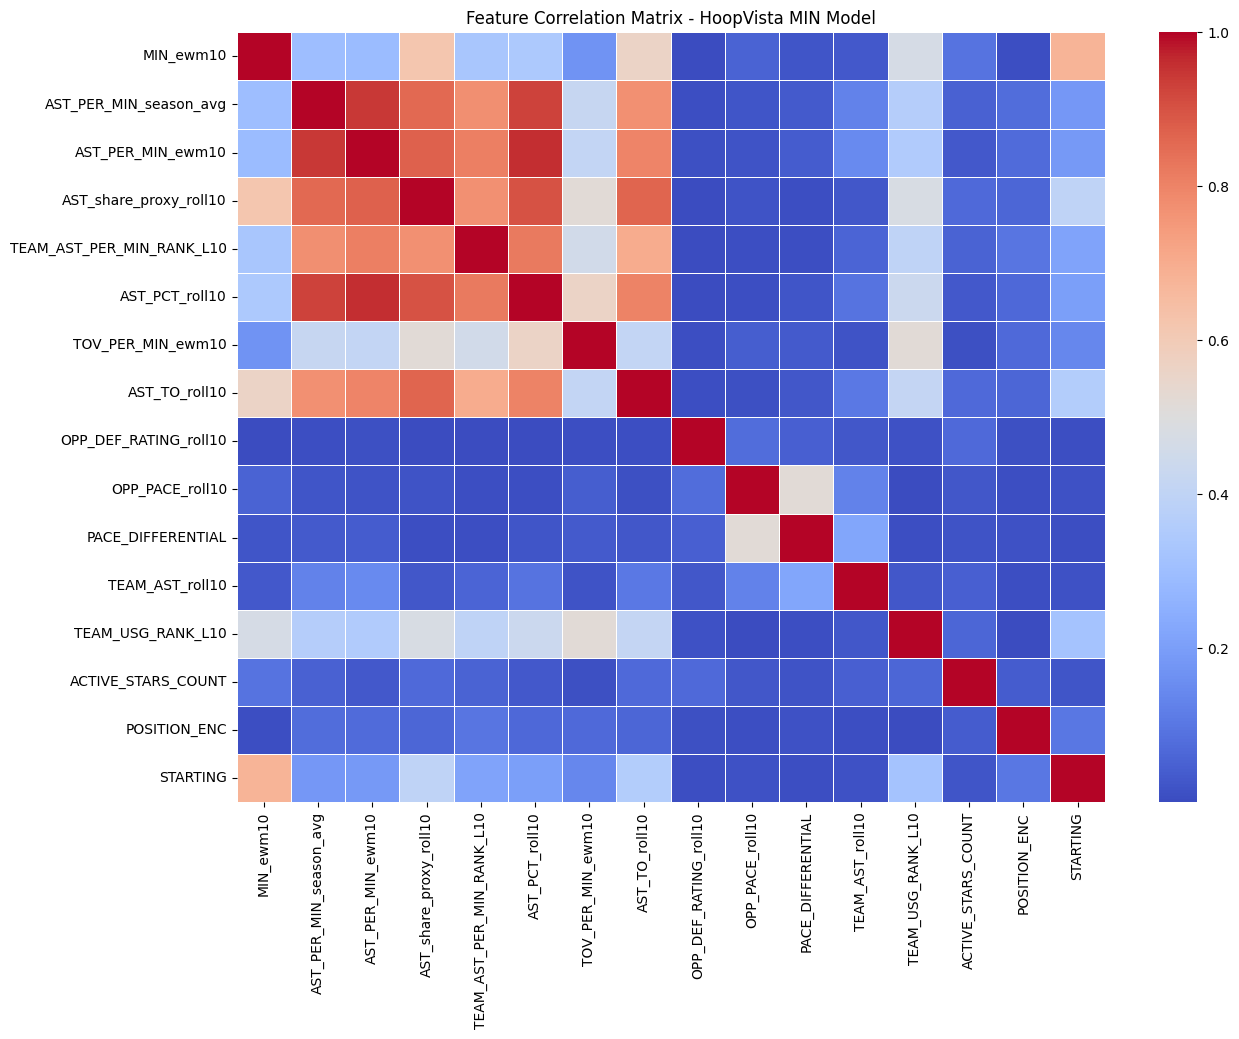

--- High Correlation Report (Threshold > 0.85) ---
AST_PCT_roll10 <-> AST_PER_MIN_ewm10: 0.9586
AST_PER_MIN_ewm10 <-> AST_PER_MIN_season_avg: 0.9443
AST_PCT_roll10 <-> AST_PER_MIN_season_avg: 0.9276
AST_PCT_roll10 <-> AST_share_proxy_roll10: 0.9001
AST_share_proxy_roll10 <-> AST_PER_MIN_ewm10: 0.8744
AST_TO_roll10 <-> AST_share_proxy_roll10: 0.8656
AST_share_proxy_roll10 <-> AST_PER_MIN_season_avg: 0.8561


['AST_PER_MIN_ewm10',
 'AST_share_proxy_roll10',
 'AST_PCT_roll10',
 'AST_TO_roll10']

In [52]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.85):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, APM_FEATURES)
correlated_features

In [53]:
import joblib
from pathlib import Path

# out_dir = Path("apm_quantile")  # or wherever you prefer
# out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "quantile_models": quantile_models,
    "feature_names": APM_FEATURES,  # or list(X_train_min.columns)
    "scaler": scaler,
}
joblib.dump(bundle, "src/models/saved_models/apm_quantile_xgb.joblib")

['src/models/saved_models/apm_quantile_xgb.joblib']

In [5]:
date = pd.Timestamp.now().normalize()  # midnight today, local tz
current_date = date.strftime("%Y-%m-%d")

# target_date = pd.Timestamp("2026-03-26")
# hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_assists')]
names = lines_dfs['NAME'].unique()
names

array(['Jalen Brunson', 'Mikal Bridges', 'Derrick White',
       'Payton Pritchard', 'Ousmane Dieng', 'Ace Bailey', 'Reed Sheppard',
       'Cody Williams', 'Scottie Barnes', 'Brandon Ingram',
       'DeMar DeRozan', 'Derik Queen', 'Devin Vassell', 'Aaron Gordon'],
      dtype=object)

In [6]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

apm_bundle = joblib.load("src/models/saved_models/apm_quantile_xgb.joblib")
apm_quantile_models = apm_bundle["quantile_models"]
apm_feature_names = apm_bundle["feature_names"]



KeyError: 'scaler'

## MIN + APM (ANALYSIS)

In [7]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name, current_date)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        apm_feats = apm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(apm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(apm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(apm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(apm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_APM_Q10": p10,
            "PRED_APM_Q50": p50,
            "PRED_APM_Q90": p90,
            "PRED_AST_Q10": round(pts10, 2),
            "PRED_AST_Q50": round(pts50, 2),
            "PRED_AST_Q90": round(pts90, 2),
            "PRED_AST_RANGE_10_90": round(pts90 - pts10, 2),
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_APM_Q10": np.nan,
            "PRED_APM_Q50": np.nan,
            "PRED_APM_Q90": np.nan,
            "PRED_AST_Q10": np.nan,
            "PRED_AST_Q50": np.nan,
            "PRED_AST_Q90": np.nan,
            "PRED_AST_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] Jalen Brunson: name 'apm_quantile_models' is not defined
[SKIP] Mikal Bridges: name 'apm_quantile_models' is not defined
[SKIP] Derrick White: name 'apm_quantile_models' is not defined
[SKIP] Payton Pritchard: name 'apm_quantile_models' is not defined
[SKIP] Ousmane Dieng: name 'apm_quantile_models' is not defined
[SKIP] Ace Bailey: name 'apm_quantile_models' is not defined
[SKIP] Reed Sheppard: name 'apm_quantile_models' is not defined
[SKIP] Cody Williams: name 'apm_quantile_models' is not defined
[SKIP] Scottie Barnes: name 'apm_quantile_models' is not defined
[SKIP] Brandon Ingram: name 'apm_quantile_models' is not defined
[SKIP] DeMar DeRozan: name 'apm_quantile_models' is not defined
[SKIP] Derik Queen: name 'apm_quantile_models' is not defined
[SKIP] Devin Vassell: name 'apm_quantile_models' is not defined
[SKIP] Aaron Gordon: name 'apm_quantile_models' is not defined


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_APM_Q10,PRED_APM_Q50,PRED_APM_Q90,PRED_AST_Q10,PRED_AST_Q50,PRED_AST_Q90,PRED_AST_RANGE_10_90
0,Jalen Brunson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mikal Bridges,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Derrick White,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Payton Pritchard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ousmane Dieng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. THE CORE SIMULATION ENGINE (POISSON-BASED)
# ---------------------------------------------------------

def triangular_clip(row, q10, q50, q90, lo_scale=0.70, hi_scale=1.30, low=0.0, high=np.inf, n_sims=10_000):
    """
    Generates a triangular distribution based on XGBoost quantiles.
    Widening the scales (lo_scale, hi_scale) introduces 'NBA Chaos' (fouls, blowouts).
    """
    mode = float(row[q50])
    # Ensure left < mode < right
    left = min(float(row[q10]) * lo_scale, mode - 0.001)
    right = max(float(row[q90]) * hi_scale, mode + 0.001)
    
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.full(n_sims, mode if np.isfinite(mode) else 0.0)
    
    # Generate continuous samples
    samples = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(samples, low, high)

def run_stat_simulation(row, stat_prefix="APM", n_sims=10_000):
    """
    Paired simulation: Minutes * Rate.
    Converts expected continuous value into discrete integers using Poisson.
    """
    # Simulate Minutes
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.75, hi_scale=1.25, low=0, high=48, n_sims=n_sims,
    )
    
    # Simulate Rate (APM or RPM)
    sim_rate = triangular_clip(
        row,
        f"PRED_{stat_prefix}_Q10", f"PRED_{stat_prefix}_Q50", f"PRED_{stat_prefix}_Q90",
        lo_scale=0.70, hi_scale=1.30, low=0, high=np.inf, n_sims=n_sims,
    )
    
    # Calculate Lambda (Expected value for each sim)
    expected_val = sim_min * sim_rate
    
    # Poisson Sampling: The 'Counting' Step
    # This turns 7.4 expected rebounds into a distribution of 6, 7, 8, 9...
    sim_counts = np.random.poisson(lam=expected_val)
    
    return sim_counts

# ---------------------------------------------------------
# 2. LINE LOOKUP & MAPPING
# ---------------------------------------------------------

def _line_lookup_from_lines_df(ldf: pd.DataFrame, name_dict: dict) -> dict:
    """
    Maps sportsbook names to canonical dataset names.
    Handles 'Jokic' vs 'Jokić' logic.
    """
    d = {}
    for _, r in ldf.iterrows():
        book_name = str(r["NAME"]).strip()
        line = r["LINE"]
        d[book_name] = line
        
        # Add the canonical version if it exists in your nameDict
        canon = name_dict.get(book_name)
        if canon:
            d[canon] = line
            
    # Reverse check: ensure variants point to the line if canon was found
    for variant, canon in name_dict.items():
        if canon in d and variant not in d:
            d[variant] = d[canon]
    return d

# ---------------------------------------------------------
# 3. EXECUTION LOOP
# ---------------------------------------------------------

# Build the lookup
line_by_name = _line_lookup_from_lines_df(lines_dfs, nameDict)

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)
    
    # Validation
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({
            "PLAYER_NAME": name, "LINE": np.nan, 
            "P_OVER": np.nan, "P_UNDER": np.nan, "P_PUSH": np.nan
        })
        continue

    # Run the Poisson Simulation (Change prefix to 'APM' for Assists)
    stat_sims = run_stat_simulation(row, stat_prefix="APM", n_sims=10_000)
    line = float(line)
    
    # Calculate Integer-Aware Probabilities
    p_over = float(np.mean(stat_sims > line))
    p_under = float(np.mean(stat_sims < line))
    p_push = float(np.mean(stat_sims == line))

    # Calculate Edge and EV
    # Assuming -119 odds (~1.84x payout) for Underdog standard
    # EV = (P_win * Profit) - (P_loss * Stake)
    # Simplified here for relative ranking:
    edge = row["PRED_AST_Q50"] - line 
    
    results.append({
        "PLAYER_NAME": name,
        "LINE": line,
        "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
        "PRED_STAT_Q50": round(row["PRED_AST_Q50"], 2),
        "P_OVER": round(p_over, 3), 
        "P_UNDER": round(p_under, 3),
        "P_PUSH": round(p_push, 3),
        "EDGE": round(edge, 2),
        "EV": round((p_over * 10) - (p_under * 10), 2) # Weighted directional EV
    })

# Create final DataFrame
line_probs_df = pd.DataFrame(results)

# Sort by absolute edge to find the biggest discrepancies
line_probs_df['ABS_EDGE'] = line_probs_df['EDGE'].abs()
line_probs_df = line_probs_df.sort_values(by="ABS_EDGE", ascending=False)

# Display top plays
print(line_probs_df[['PLAYER_NAME', 'LINE', 'PRED_STAT_Q50', 'P_OVER', 'P_UNDER', 'P_PUSH', 'EDGE']].head(15))

         PLAYER_NAME  LINE  PRED_STAT_Q50  P_OVER  P_UNDER  P_PUSH  EDGE
8     Scottie Barnes   8.5           7.28   0.417    0.583     0.0 -1.22
5         Ace Bailey   2.5           1.59   0.375    0.625     0.0 -0.91
6      Reed Sheppard   4.5           3.78   0.457    0.543     0.0 -0.72
7      Cody Williams   3.5           2.78   0.403    0.597     0.0 -0.72
3   Payton Pritchard   4.5           3.79   0.422    0.578     0.0 -0.71
10     DeMar DeRozan   4.5           5.18   0.646    0.354     0.0  0.68
4      Ousmane Dieng   4.5           3.96   0.463    0.537     0.0 -0.54
9     Brandon Ingram   3.5           3.99   0.669    0.331     0.0  0.49
13      Aaron Gordon   2.5           2.88   0.680    0.320     0.0  0.38
12     Devin Vassell   2.5           2.83   0.691    0.309     0.0  0.33
0      Jalen Brunson   7.5           7.26   0.524    0.476     0.0 -0.24
1      Mikal Bridges   3.5           3.34   0.581    0.419     0.0 -0.16
2      Derrick White   4.5           4.66   0.603  